2.7.1+cu128
True
NVIDIA GeForce RTX 5060 Laptop GPU


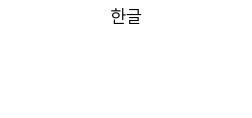

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams

print(torch.__version__)
print(torch.cuda.is_available())     
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [2]:
# 교재 Chapter 3

print(torch.tensor([1, 2, 3]))
print(torch.tensor([[1, 2, 3], [4, 5, 6]]))
print(torch.LongTensor([1, 2, 3]))
print(torch.FloatTensor([1, 2, 3]))

tensor([1, 2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([1, 2, 3])
tensor([1., 2., 3.])


In [3]:
tensor = torch.rand(1, 2)
print(tensor.shape)
print(tensor.dtype)
print(tensor.device)

torch.Size([1, 2])
torch.float32
cpu


In [4]:
tensor = tensor.reshape(2, 1)
print(tensor)
print(tensor.shape)

tensor([[0.9019],
        [0.0597]])
torch.Size([2, 1])


In [5]:
# 텐서 자료형 바꾸기
tensor = torch.rand((3, 3), dtype = torch.float)
print(tensor)

tensor([[0.3539, 0.2034, 0.3921],
        [0.1924, 0.7508, 0.4720],
        [0.3931, 0.0607, 0.4751]])


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
cpu = torch.FloatTensor([1, 2, 3])
gpu = torch.cuda.FloatTensor([1, 2, 3])
tensor = torch.rand((1, 1), device = device)
print(cpu)
print(gpu)
print(tensor)

tensor([1., 2., 3.])
tensor([1., 2., 3.], device='cuda:0')
tensor([[0.4583]], device='cuda:0')


C:\Users\KDT-17\AppData\Local\Temp\ipykernel_27644\4063380246.py:2: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  gpu = torch.cuda.FloatTensor([1, 2, 3])


In [8]:
# 장치 변환
cpu = torch.FloatTensor([1, 2, 3])
gpu = cpu.cuda()
gpu2cpu = gpu.cpu()
cpu2gpu = cpu.to(device) # "cuda" 도 가능

In [9]:
import numpy as np

ndarray = np.array([1, 2, 3], dtype = np.uint8)
print(torch.tensor(ndarray))
print(torch.Tensor(ndarray))
print(torch.from_numpy(ndarray))

tensor([1, 2, 3], dtype=torch.uint8)
tensor([1., 2., 3.])
tensor([1, 2, 3], dtype=torch.uint8)


In [10]:
tensor = torch.cuda.FloatTensor([1, 2, 3])
ndarray = tensor.detach().cpu().numpy()
print(ndarray)
print(type(ndarray))

[1. 2. 3.]
<class 'numpy.ndarray'>


In [11]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [12]:
# 비선형회귀 class만들어서 실행

class CustomDataset(Dataset):
    def __init__(self, file_path):
        df = pd.read_csv(file_path)
        self.x = df.iloc[:, 0].values
        self.y = df.iloc[:, 1].values
        self.length = len(df)
    def __getitem__(self, index):
        x = torch.FloatTensor([self.x[index] ** 2, self.x[index]])
        y = torch.FloatTensor([self.y[index]])
        return x, y
    def __len__(self):
        return self.length

In [13]:
class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(2, 1)
    def forward(self, x):
        x = self.layer(x)
        return x

In [14]:
dataset = CustomDataset("data/non_linear.csv")
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = int(dataset_size * 0.1)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset,
                                                        [train_size,
                                                        val_size,
                                                        test_size])

train_dataloader = DataLoader(train_dataset,
                              batch_size = 16,
                              shuffle = True,
                              drop_last = True)
val_dataloader = DataLoader(val_dataset,
                              batch_size = 4,
                              shuffle = True,
                              drop_last = True)
test_dataloader = DataLoader(test_dataset,
                              batch_size = 4,
                              shuffle = False,
                              drop_last = True)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomModel().to(device)
criterion = nn.MSELoss().to(device)
optimizer = optim.SGD(model.parameters(), lr = 0.0001)

In [16]:
checkpoint = 1
for epoch in range(1000):
    cost = 0.0 # 책에서 Loss를 cost로 표현
    for x, y in train_dataloader:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        cost += loss
    cost = cost / len(train_dataloader)
    if (epoch + 1) % 100 == 0:
        print(epoch + 1, cost)
        torch.save(model.state_dict(), f"models/checkpoint-{checkpoint}.pt")
        checkpoint += 1

100 tensor(0.1550, device='cuda:0', grad_fn=<DivBackward0>)
200 tensor(0.1443, device='cuda:0', grad_fn=<DivBackward0>)
300 tensor(0.1341, device='cuda:0', grad_fn=<DivBackward0>)
400 tensor(0.1245, device='cuda:0', grad_fn=<DivBackward0>)
500 tensor(0.1140, device='cuda:0', grad_fn=<DivBackward0>)
600 tensor(0.1103, device='cuda:0', grad_fn=<DivBackward0>)
700 tensor(0.1032, device='cuda:0', grad_fn=<DivBackward0>)
800 tensor(0.0994, device='cuda:0', grad_fn=<DivBackward0>)
900 tensor(0.0967, device='cuda:0', grad_fn=<DivBackward0>)
1000 tensor(0.0931, device='cuda:0', grad_fn=<DivBackward0>)


In [18]:
with torch.no_grad():
    model.eval()
    # inputs = torch.FloatTensor([[1 ** 2, 1],
    #                             [5 ** 2, 5],
    #                             [11 * 2, 11]]).to(device)
    for x, y in val_dataloader:
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        print(outputs)

tensor([[  0.7868],
        [ 81.6078],
        [128.2031],
        [ 25.7256]], device='cuda:0')
tensor([[ 33.3573],
        [  8.7880],
        [182.8404],
        [ 22.2820]], device='cuda:0')
tensor([[215.1697],
        [ 11.5939],
        [ 18.3446],
        [290.5047]], device='cuda:0')
tensor([[ 16.8703],
        [ 20.6534],
        [ 13.4409],
        [287.5814]], device='cuda:0')
tensor([[ 60.8621],
        [171.1823],
        [  6.3946],
        [103.5519]], device='cuda:0')


In [19]:
torch.save(model, "models/model.pt")

In [20]:
torch.save(model.state_dict(), "models/model_state_dict.pt")

In [21]:
model = torch.load("models/model.pt", map_location = device, weights_only = False) # 저장한 것 불러오기

In [ ]:
print(model)

CustomModel(
  (layer): Linear(in_features=2, out_features=1, bias=True)
)


In [22]:
model_state_dict = torch.load("models/model_state_dict.pt", map_location = device, weights_only = False)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [23]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class CustomDataset(Dataset):
    def __init__(self, file_path):
        df = pd.read_csv(file_path)
        self.x1 = df.iloc[:, 0].values
        self.x2 = df.iloc[:, 1].values
        self.x3 = df.iloc[:, 2].values
        self.y = df.iloc[:, 3].values
        self.length = len(df)
    def __getitem__(self, index):
        x = torch.FloatTensor([self.x1[index], self.x2[index], self.x3[index]])
        y = torch.FloatTensor([int(self.y[index])])
        return x, y
    def __len__(self):
        return self.length

In [24]:
class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(nn.Linear(3, 1),
                                   nn.Sigmoid())
    def forward(self, x):
        x = self.layer(x)
        return x

In [25]:
dataset = CustomDataset("data/binary.csv")
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = int(dataset_size * 0.1)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset,
                                                        [train_size, val_size, test_size],
                                                        torch.manual_seed(42))

train_dataloader = DataLoader(train_dataset,
                              batch_size = 64,
                              shuffle = True,
                              drop_last = True)
val_dataloader = DataLoader(val_dataset,
                              batch_size = 4,
                              shuffle = True,
                              drop_last = True)
test_dataloader = DataLoader(test_dataset,
                              batch_size = 4,
                              shuffle = False,
                              drop_last = True)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomModel().to(device)
criterion = nn.BCELoss().to(device)
optimizer = optim.SGD(model.parameters(), lr = 0.0001)

In [27]:
for epoch in range(1000):
    cost = 0.0
    for x, y in train_dataloader:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost = cost / len(train_dataloader)
    if (epoch + 1) % 100 == 0:
        print(epoch, cost)

99 0.0
199 0.0
299 0.0
399 0.0
499 0.0
599 0.0
699 0.0
799 0.0
899 0.0
999 0.0


In [28]:
with torch.no_grad():
    model.eval()
    for x, y in val_dataloader:
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        print(outputs)
        print(outputs >= torch.FloatTensor([0.5]).to(device))

tensor([[0.5864],
        [0.6288],
        [0.5761],
        [0.6140]], device='cuda:0')
tensor([[True],
        [True],
        [True],
        [True]], device='cuda:0')
tensor([[0.5202],
        [0.5756],
        [0.5130],
        [0.4772]], device='cuda:0')
tensor([[ True],
        [ True],
        [ True],
        [False]], device='cuda:0')
tensor([[0.6777],
        [0.5835],
        [0.6335],
        [0.5743]], device='cuda:0')
tensor([[True],
        [True],
        [True],
        [True]], device='cuda:0')
tensor([[0.6354],
        [0.6799],
        [0.6377],
        [0.4774]], device='cuda:0')
tensor([[ True],
        [ True],
        [ True],
        [False]], device='cuda:0')
tensor([[0.5836],
        [0.5882],
        [0.4988],
        [0.5508]], device='cuda:0')
tensor([[ True],
        [ True],
        [False],
        [ True]], device='cuda:0')
tensor([[0.6204],
        [0.5944],
        [0.5406],
        [0.6835]], device='cuda:0')
tensor([[True],
        [True],
      